In [71]:
from utils.paths import SAMPLING_DIR, RAW_DIR,PREDICTIONS_DIR,PLOTS_DIR

In [72]:
import numpy as np
import pandas as pd
import pickle

from sklearn.preprocessing import StandardScaler
from preprocessing.TernaryPlot import plot_ternary_heatmap
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [73]:
with open(PREDICTIONS_DIR/"ANN_Predictions/ANN_e2_experiment_prediction.pkl", "rb") as f:
    simu_data = pickle.load(f)

In [74]:
with open(PREDICTIONS_DIR/"ANN_Predictions/TL_ANN/ann_random_split.pkl", "rb") as f:
    random_pred = pickle.load(f)
with open(PREDICTIONS_DIR/"ANN_Predictions/TL_ANN/ann_cluster_split.pkl", "rb") as f:
    cluster_pred = pickle.load(f)
with open(SAMPLING_DIR/"random_split", "rb") as f:
    random_split = pickle.load(f)
with open(SAMPLING_DIR/"cluster_split", "rb") as f:
    cluster_split = pickle.load(f)

comp_space = pd.read_csv(RAW_DIR/"CuNiAl_descriptors.csv")

In [75]:
cluster_split['y_test']

8     47.435261
9     55.827915
1     15.960722
4     64.696091
23    49.449562
11    69.396393
Name: e2, dtype: float64

Simulation Model test

In [76]:
comp_colum = ['Cu','Ni','Al']
df_experimental = pd.concat(
    [random_split['X_train_split'][comp_colum], random_split['X_test_split'][comp_colum]],
    axis=0,
    ignore_index=True
)

e2_experimental = np.concatenate(
    [random_split['y_train'], random_split['y_test']],
    axis=0
)

df_experimental['e2'] = e2_experimental


df_compare = simu_data.merge(
    df_experimental,
    on=comp_colum,
    how="inner",
    suffixes=("_sim", "_exp")
)

In [77]:
simulation_test = {}

simulation_test["mae"] = mean_absolute_error(df_compare["e2_exp"], df_compare["e2_sim"])
simulation_test["rmse"] = np.sqrt(mean_squared_error(df_compare["e2_exp"], df_compare["e2_sim"]))
simulation_test["r2"] = r2_score(df_compare["e2_exp"], df_compare["e2_sim"])


print(f"MAE : {simulation_test['mae']:.4g}")
print(f"RMSE: {simulation_test['rmse']:.4g}")
print(f"R^2 : {simulation_test['r2']:.4g}")

MAE : 16.94
RMSE: 22.12
R^2 : -1.149


In [78]:
df_compare["e2_error"] = df_compare["e2_exp"] - df_compare["e2_sim"]
df_compare["e2_abs_error"] = np.abs(df_compare["e2_error"])
df_compare["e2_error_sq"] = df_compare["e2_error"] ** 2

df_compare[comp_colum] = df_compare[comp_colum]*100

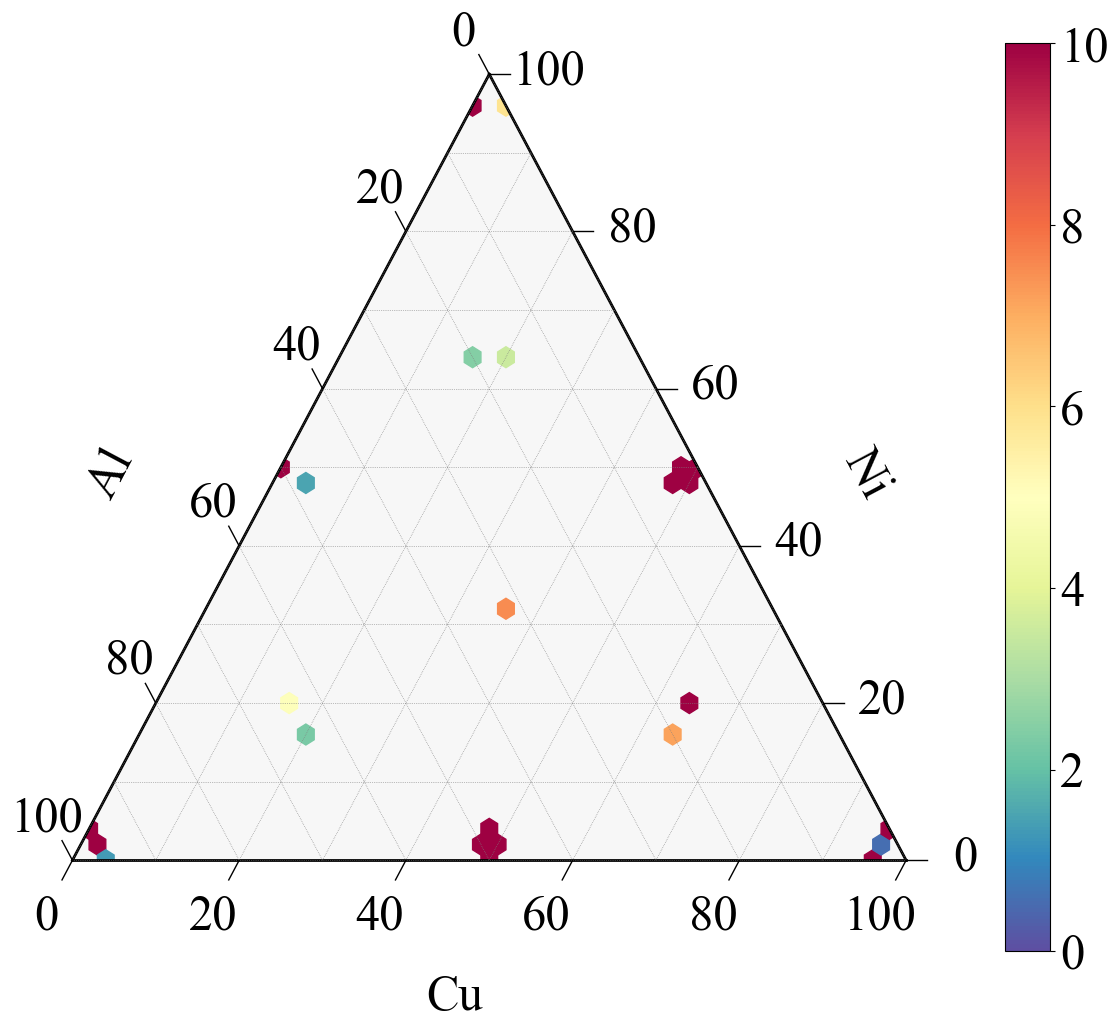

In [79]:
fig, tax = plot_ternary_heatmap(
    df=df_compare,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2_abs_error",
    scale=50,
    cmap="Spectral_r",
    vmin=0,
    vmax=10,
    show=True,
    duplicate_handling="mean",
)
fig.savefig(PLOTS_DIR/"ternary_e2_error_ANN_Sim.svg", bbox_inches="tight")

In [80]:
random_pred['mae'] = mean_absolute_error(random_pred['y_test_pred'], random_split['y_test'])
random_pred['rmse'] = np.sqrt(mean_squared_error(random_pred['y_test_pred'], random_split['y_test']))
random_pred['r2'] = r2_score(random_pred['y_test_pred'], random_split['y_test'])


print(f"MAE : {random_pred['mae']:.4g}")
print(f"RMSE: {random_pred['rmse']:.4g}")
print(f"R^2 : {random_pred['r2']:.4g}")

MAE : 21.16
RMSE: 23.41
R^2 : -11.98


In [81]:
columns = ['Cu','Ni','Al']
df_rand_split = comp_space[columns].copy()*100

df_rand_split["e2"] = random_pred['all_space_pred']

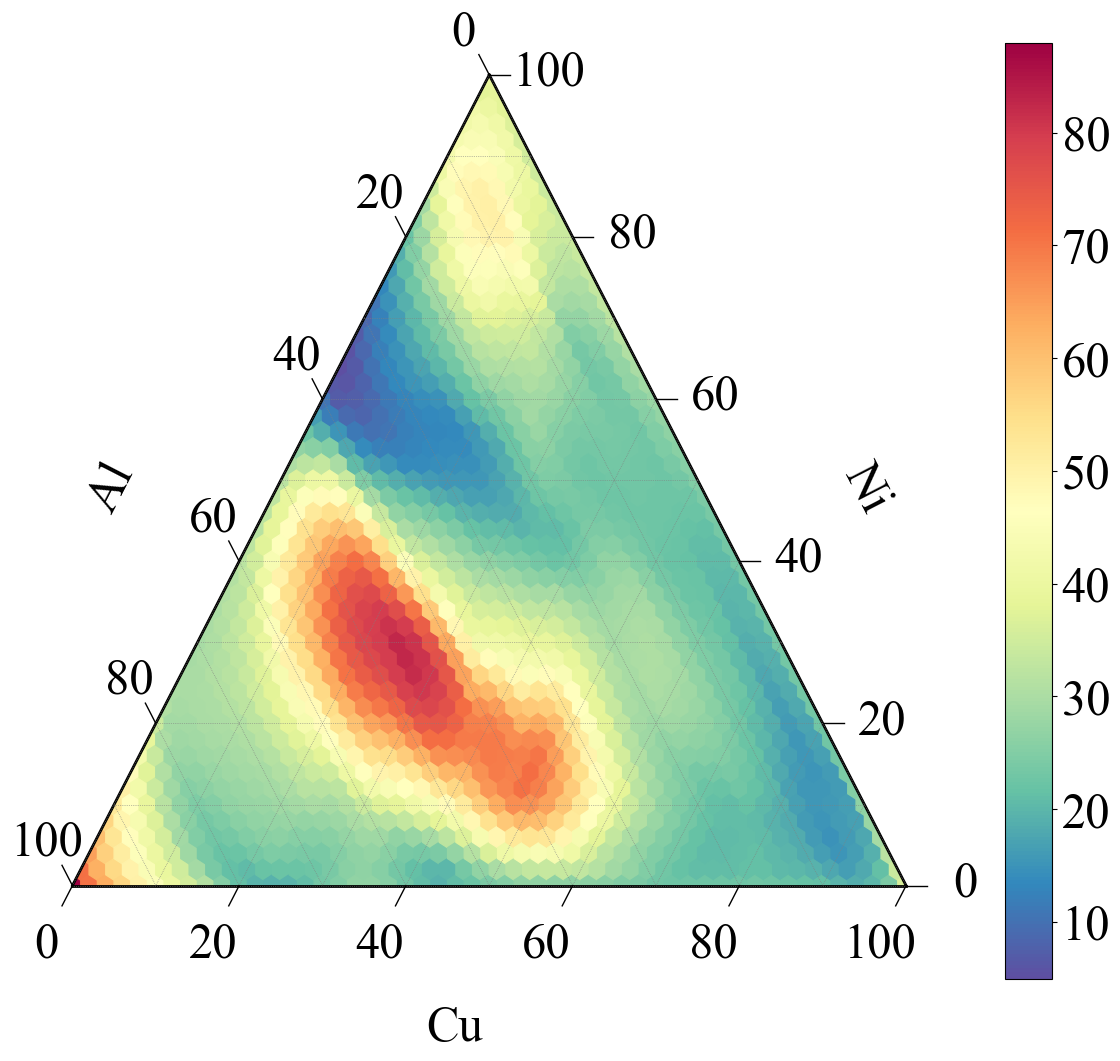

In [82]:
fig, tax = plot_ternary_heatmap(
    df=df_rand_split,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)

In [83]:
cluster_pred['mae'] = mean_absolute_error(cluster_pred['y_test_pred'], cluster_split['y_test'])
cluster_pred['rmse'] = np.sqrt(mean_squared_error(cluster_pred['y_test_pred'], cluster_split['y_test']))
cluster_pred['r2'] = r2_score(cluster_pred['y_test_pred'], cluster_split['y_test'])


print(f"MAE : {cluster_pred['mae']:.4g}")
print(f"RMSE: {cluster_pred['rmse']:.4g}")
print(f"R^2 : {cluster_pred['r2']:.4g}")

MAE : 18.14
RMSE: 19.64
R^2 : -1.23


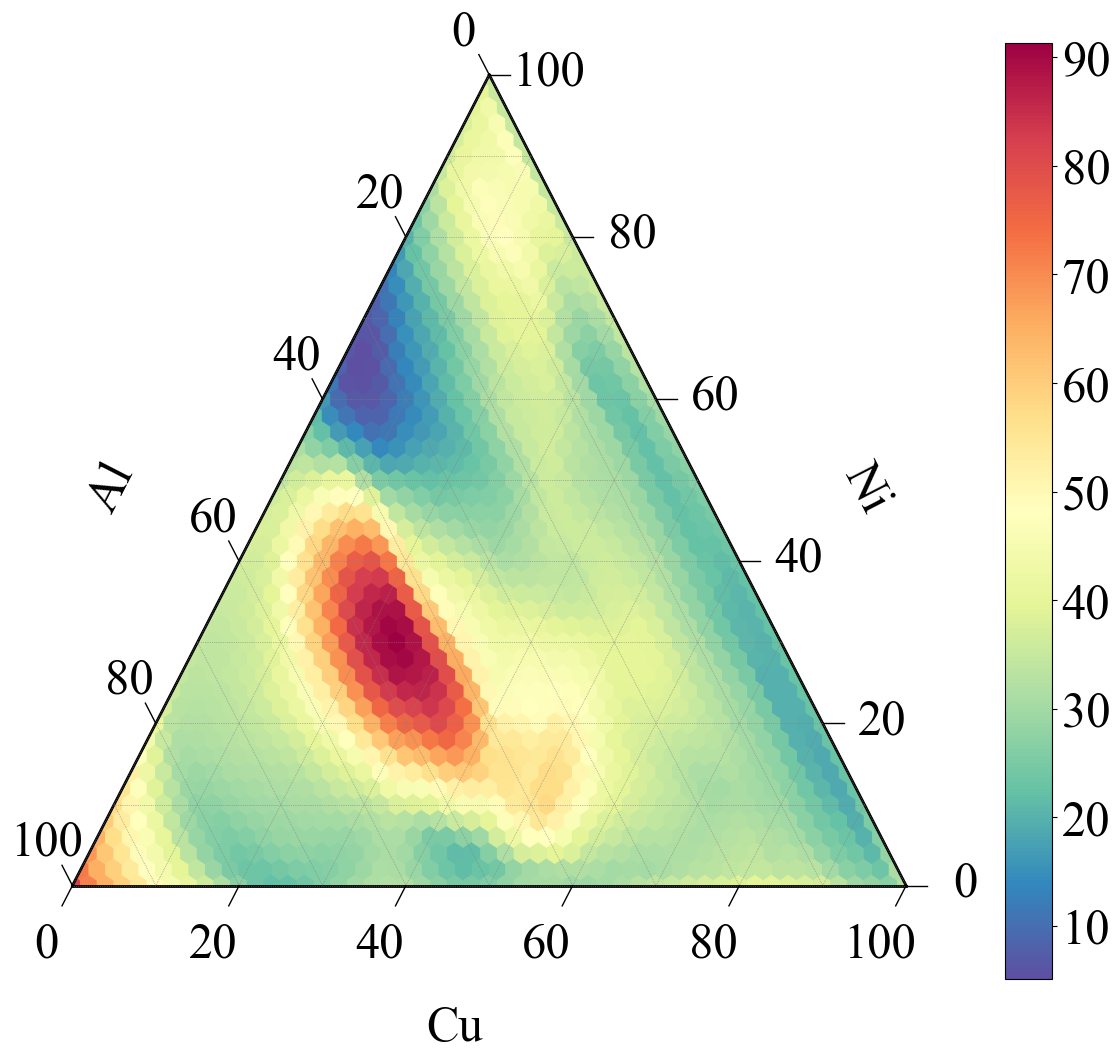

In [84]:
columns = ['Cu','Ni','Al']
df_clus_split = comp_space[columns].copy()*100

df_clus_split["e2"] = cluster_pred['all_space_pred']

fig, tax = plot_ternary_heatmap(
    df=df_clus_split,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)
fig.savefig(PLOTS_DIR/"ternary_ANN_transfer.svg", bbox_inches="tight")

In [85]:
df_comp_ann = cluster_split['X_test_split'].copy()
df_comp_ann['e2_error'] = cluster_split['y_test'] - cluster_pred['y_test_pred'].ravel()
df_comp_ann["e2_abs_error"] = np.abs(df_comp_ann["e2_error"])
df_comp_ann["e2_error_sq"] = df_comp_ann["e2_error"] ** 2

df_comp_ann[comp_colum] = df_comp_ann[comp_colum]*100

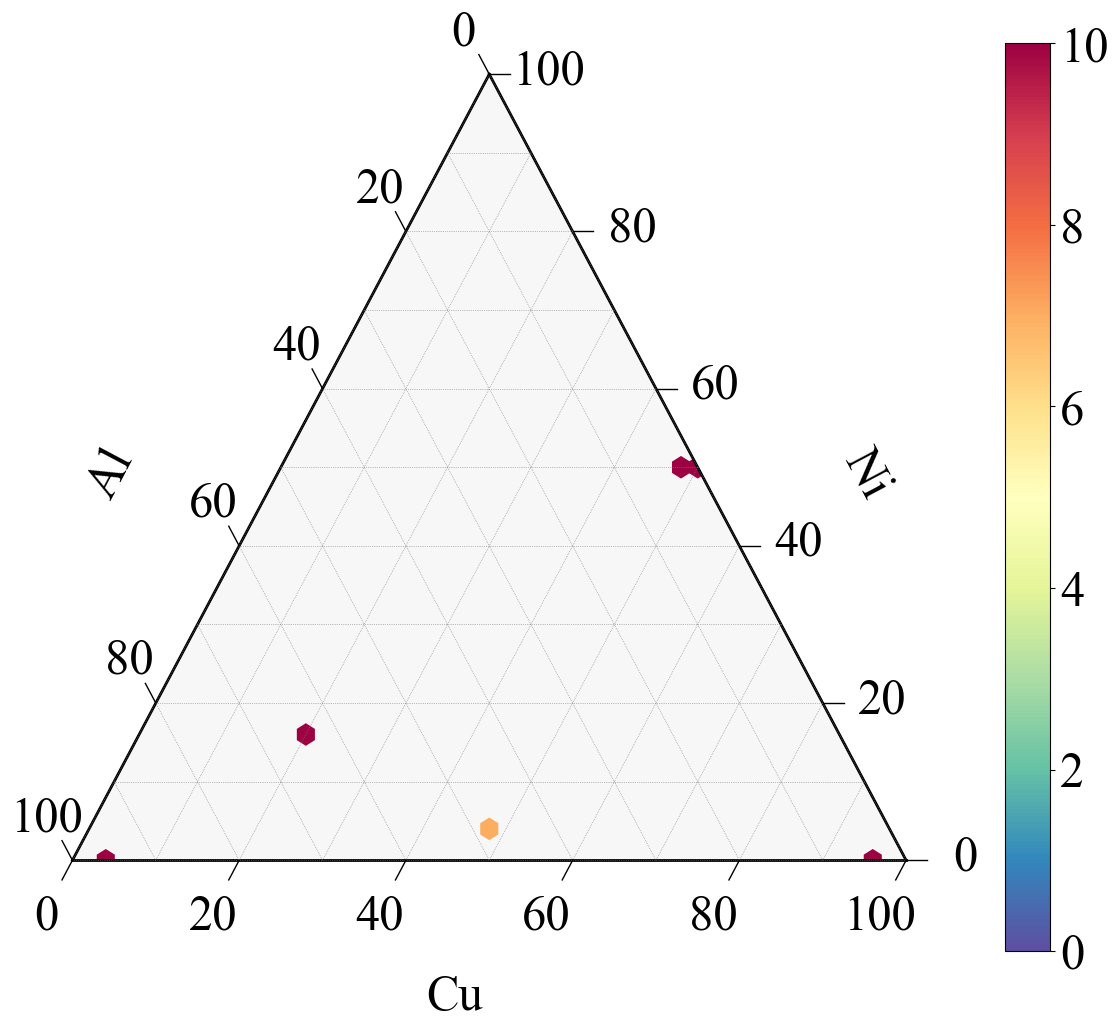

In [86]:
fig, tax = plot_ternary_heatmap(
    df=df_comp_ann,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2_abs_error",
    scale=50,
    cmap="Spectral_r",
    vmin=0,
    vmax=10,
    show=True,
    duplicate_handling="mean",
)
fig.savefig(PLOTS_DIR/"ternary_e2_error_ANN_transfer.svg", bbox_inches="tight")